# 01 – Data Acquisition: Hourly Temperature Observations (2012)

## Objective

This notebook retrieves raw hourly temperature observations for Oklahoma (starting with Oklahoma City) for the year 2012.

We will collect raw observational data from:

- NOAA surface observation stations
- Oklahoma Mesonet stations
- Potential additional observational networks

The goal of this notebook is **not analysis**.  
The goal is to:

1. Retrieve reproducible raw data
2. Preserve it in original form
3. Store it in the `data/raw/` directory
4. Document metadata and station details

This notebook establishes the foundation for the entire Weather Agreement Lab.

Downstream notebooks will:
- Clean and align this data
- Measure agreement between agencies
- Build a machine learning-based fusion model

In [22]:
# If running inside a fresh environment, uncomment:
# !pip install requests pandas python-dotenv

import os
import requests
import pandas as pd
from datetime import datetime

In [23]:
import sys
import os
import platform
import subprocess
from datetime import datetime
import pkg_resources

print("===== SESSION DIAGNOSTICS =====\n")

print("Timestamp:", datetime.now())
print("\n--- Python ---")
print("Python version:", sys.version)
print("Python executable:", sys.executable)

print("\n--- Virtual Environment ---")
print("VIRTUAL_ENV:", os.environ.get("VIRTUAL_ENV"))

print("\n--- Working Directory ---")
print("Current working directory:", os.getcwd())

print("\n--- Platform ---")
print("System:", platform.system())
print("Release:", platform.release())
print("Machine:", platform.machine())
print("Processor:", platform.processor())

print("\n--- Installed Key Packages ---")
for pkg in ["pandas", "requests", "python-dotenv"]:
    try:
        version = pkg_resources.get_distribution(pkg).version
        print(f"{pkg}: {version}")
    except Exception:
        print(f"{pkg}: NOT INSTALLED")

print("\n--- Git Status ---")
try:
    result = subprocess.run(
        ["git", "rev-parse", "--abbrev-ref", "HEAD"],
        capture_output=True,
        text=True
    )
    print("Git branch:", result.stdout.strip())
except Exception:
    print("Git not available")

print("\n==============================")

===== SESSION DIAGNOSTICS =====

Timestamp: 2026-03-06 11:29:41.239301

--- Python ---
Python version: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Python executable: c:\Users\evertj\git\handson-ml3\Weather_Agreement_Lab\.venv\Scripts\python.exe

--- Virtual Environment ---
VIRTUAL_ENV: C:\Users\evertj\git\handson-ml3\Weather_Agreement_Lab\.venv

--- Working Directory ---
Current working directory: c:\Users\evertj\git\handson-ml3\Weather_Agreement_Lab

--- Platform ---
System: Windows
Release: 10
Machine: AMD64
Processor: Intel64 Family 6 Model 151 Stepping 2, GenuineIntel

--- Installed Key Packages ---
pandas: 3.0.1
requests: 2.32.5
python-dotenv: 1.2.1

--- Git Status ---
Git branch: main



In [24]:
from pathlib import Path

PROJECT_ROOT = Path().resolve()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

print(DATA_RAW)

C:\Users\evertj\git\handson-ml3\Weather_Agreement_Lab\data\raw


In [25]:
assert ".venv" in sys.executable, "WARNING: You are not using the project virtual environment!"


In [26]:
from dotenv import load_dotenv

load_dotenv()

NOAA_TOKEN = os.getenv("NOAA_TOKEN")

if NOAA_TOKEN is None:
    raise ValueError("NOAA_TOKEN not found in .env file.")

headers = {"token": NOAA_TOKEN}

print("NOAA token loaded successfully.")

NOAA token loaded successfully.


In [27]:
test_url = "https://www.ncei.noaa.gov/cdo-web/api/v2/datasets"

response = requests.get(test_url, headers=headers)

print("Status Code:", response.status_code)

Status Code: 200


In [28]:
from pathlib import Path

root = Path.cwd()
raw = root / "data" / "raw"
processed = root / "data" / "processed"

print("Root:", root)
print("Raw:", raw.exists())
print("Processed:", processed.exists())
print("Raw contents:", list(raw.glob("*")))

Root: c:\Users\evertj\git\handson-ml3\Weather_Agreement_Lab
Raw: True
Processed: True
Raw contents: [WindowsPath('c:/Users/evertj/git/handson-ml3/Weather_Agreement_Lab/data/raw/image.png'), WindowsPath('c:/Users/evertj/git/handson-ml3/Weather_Agreement_Lab/data/raw/noaa_okc_2012_hourly.gz'), WindowsPath('c:/Users/evertj/git/handson-ml3/Weather_Agreement_Lab/data/raw/noaa_okc_2012_hourly.txt')]


In [29]:
import pandas as pd

df = pd.read_csv(
    "data/raw/noaa_okc_2012_hourly.txt",
    sep=",",
    low_memory=False
)

print(df.head())
print(df.columns)
print(df.shape)

  0203723530139672012010100004+35383-097600FM-12+0398KOKC V0203401N012312200019N0160001N1+01671+00061101191ADDGF102991999999999999999999KA1120M+02171KA2180N+00171MD1310721+9999OC101655REMSYN098AAXX  01004 72353 32966 23424 10167 20006 39662 40119 53072 92352 333 10217 20017 91032 555 90100;EQDQ01+096623APOSP 
0  0245723530139672012010100527+35389-097601FM-15...                                                                                                                                                                                                                                                                  
1  0245723530139672012010101527+35389-097601FM-15...                                                                                                                                                                                                                                                                  
2  0265723530139672012010102527+35389-097601FM-15...               

In [30]:

import pandas as pd

df = pd.read_csv("data/raw/noaa_okc_2012_hourly.txt")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13435 entries, 0 to 13434
Data columns (total 1 columns):
 #   Column                                                                                                                                                                                                                                                                                                                Non-Null Count  Dtype
---  ------                                                                                                                                                                                                                                                                                                                --------------  -----
 0   0203723530139672012010100004+35383-097600FM-12+0398KOKC V0203401N012312200019N0160001N1+01671+00061101191ADDGF102991999999999999999999KA1120M+02171KA2180N+00171MD1310721+9999OC101655REMSYN098AAXX  01004 72353 32966 23424 101

In [31]:
import os
import requests
from dotenv import load_dotenv

load_dotenv()

token = os.getenv("NOAA_TOKEN")

url = "https://www.ncei.noaa.gov/cdo-web/api/v2/stations"

params = {
    "datasetid": "GHCND",
    "locationid": "FIPS:40",   # Oklahoma
    "limit": 10
}

headers = {
    "token": token
}

response = requests.get(url, headers=headers, params=params)

stations = response.json()

print("Status:", response.status_code)
print("Keys returned:", stations.keys())
print("Number of stations returned:", len(stations.get("results", [])))

for s in stations.get("results", []):
    print(s["id"], "-", s["name"])

Status: 200
Keys returned: dict_keys(['metadata', 'results'])
Number of stations returned: 10
GHCND:US1OKAD0002 - BUNCH 0.8 N, OK US
GHCND:US1OKAD0003 - WESTVILLE 0.2 ENE, OK US
GHCND:US1OKAD0004 - WESTVILLE 3.0 SSW, OK US
GHCND:US1OKAD0006 - WATTS 7.2 WSW, OK US
GHCND:US1OKAL0002 - JET 6.0 NNE, OK US
GHCND:US1OKAT0003 - BOSWELL 9.9 N, OK US
GHCND:US1OKBC0002 - SAYRE 5.6 N, OK US
GHCND:US1OKBC0005 - SAYRE 5.8 NW, OK US
GHCND:US1OKBC0009 - ELK CITY 1.9 WSW, OK US
GHCND:US1OKBC0013 - ELK CITY 1.2 NNE, OK US


In [32]:
base_url = "https://www.ncei.noaa.gov/cdo-web/api/v2/stations"



params = {
    "datasetid": "GHCND",
    "locationid": "FIPS:40",
    "limit": 1000
}

response = requests.get(base_url, headers=headers, params=params)

stations = response.json()
stations_df = pd.DataFrame(stations["results"])

stations_df.head()

,elevation,mindate,maxdate,latitude,name,datacoverage,id,elevationUnit,longitude
0,281.9,2008-04-06,2026-02-26,35.692100,"BUNCH 0.8 N, OK US",0.9198,GHCND:US1OKAD0002,METERS,-94.769400
1,345.0,2011-01-12,2020-06-12,35.990160,"WESTVILLE 0.2 ENE, OK US",0.9977,GHCND:US1OKAD0003,METERS,-94.571557
2,337.1,2013-04-26,2023-05-13,35.952917,"WESTVILLE 3.0 SSW, OK US",0.1897,GHCND:US1OKAD0004,METERS,-94.602300
3,338.9,2019-08-11,2026-02-21,36.077200,"WATTS 7.2 WSW, OK US",0.2032,GHCND:US1OKAD0006,METERS,-94.694440
4,346.9,2020-09-26,2026-02-14,36.751500,"JET 6.0 NNE, OK US",0.0940,GHCND:US1OKAL0002,METERS,-98.155000


In [33]:
stations_df[stations_df["name"].str.contains("OKLAHOMA CITY", case=False)]

,elevation,mindate,maxdate,latitude,name,datacoverage,id,elevationUnit,longitude
164,372.8,2012-08-17,2026-02-27,35.310000,"OKLAHOMA CITY 10.9 S, OK US",0.9308,GHCND:US1OKCV0091,METERS,-97.525800
183,370.6,2015-06-18,2021-07-11,35.300400,"OKLAHOMA CITY 11.5 S, OK US",0.2369,GHCND:US1OKCV0120,METERS,-97.519000
200,371.6,2019-04-13,2022-04-04,35.335000,"OKLAHOMA CITY 9.2 S, OK US",0.2803,GHCND:US1OKCV0149,METERS,-97.525200
202,397.5,2019-09-18,2026-02-25,35.376982,"OKLAHOMA CITY 7.8 SE, OK US",0.7846,GHCND:US1OKCV0155,METERS,-97.429791
371,352.7,2008-03-18,2023-11-02,35.520594,"OKLAHOMA CITY 3.8 NNW, OK US",0.8157,GHCND:US1OKOK0019,METERS,-97.532261
374,381.6,2008-08-19,2017-04-21,35.487694,"OKLAHOMA CITY 1.7 NNW, OK US",0.1604,GHCND:US1OKOK0026,METERS,-97.529444
379,389.5,2009-08-17,2012-11-10,35.395784,"OKLAHOMA CITY 5.0 S, OK US",0.1041,GHCND:US1OKOK0034,METERS,-97.496237
380,361.2,2012-03-08,2013-10-12,35.590324,"OKLAHOMA CITY 8.7 NNW, OK US",0.1866,GHCND:US1OKOK0042,METERS,-97.560341
384,394.4,2012-08-09,2014-03-06,35.382103,"OKLAHOMA CITY 6.5 SSW, OK US",0.2852,GHCND:US1OKOK0050,METERS,-97.564485
389,353.0,2015-05-18,2018-11-30,35.590377,"OKLAHOMA CITY 9.4 NNE, OK US",0.9652,GHCND:US1OKOK0065,METERS,-97.443874


In [34]:
import requests

base_dir = "https://www.ncei.noaa.gov/data/global-hourly/archive/csv/2012/"

response = requests.get(base_dir)
print("Status:", response.status_code)

print(response.text[:2000])

Status: 404
<!DOCTYPE HTML PUBLIC "-//IETF//DTD HTML 2.0//EN">
<html><head>
<title>404 Not Found</title>
</head><body>
<h1>Not Found</h1>
<p>The requested URL was not found on this server.</p>
</body></html>



In [35]:
if response.status_code == 200:
    if "723530" in response.text:
        print("Found 723530 in directory listing!")
    else:
        print("723530 not found in listing.")

In [36]:
import os
import requests

url = "https://www.ncei.noaa.gov/pub/data/noaa/2012/723530-13967-2012.gz"
save_path = "data/raw/noaa_okc_2012_hourly.gz"

print("Downloading from:", url)

os.makedirs("data/raw", exist_ok=True)

response = requests.get(url)
print("Status code:", response.status_code)

response.raise_for_status()

with open(save_path, "wb") as f:
    f.write(response.content)

print("Download complete.")
print("File size (bytes):", os.path.getsize(save_path))

Status code: 200
Download complete.
File size (bytes): 805821


In [37]:
import gzip

source_path = "data/raw/noaa_okc_2012_hourly.gz"
decompressed_path = "data/raw/noaa_okc_2012_hourly.txt"

with gzip.open(source_path, 'rb') as f_in:
    with open(decompressed_path, 'wb') as f_out:
        f_out.write(f_in.read())

print("Decompressed file created.")
print("File size:", os.path.getsize(decompressed_path), "bytes")

Decompressed file created.
File size: 4711388 bytes


In [38]:
with open(decompressed_path, 'r') as f:
    for _ in range(5):
        print(f.readline())

0203723530139672012010100004+35383-097600FM-12+0398KOKC V0203401N012312200019N0160001N1+01671+00061101191ADDGF102991999999999999999999KA1120M+02171KA2180N+00171MD1310721+9999OC101655REMSYN098AAXX  01004 72353 32966 23424 10167 20006 39662 40119 53072 92352 333 10217 20017 91032 555 90100;EQDQ01+096623APOSP 

0245723530139672012010100527+35389-097601FM-15+0397KOKC V0303305N010852200059N0160935N5+01505-00395101445ADDAA101000095GA1025+076205999GD11991+0762059GF102991999999999999999999MA1101465096775OC101395OD130101491330REMMET12812/31/11 18:52:03 METAR KOKC 010052Z 33021G27KT 10SM FEW250 15/M04 A2996 RMK AO2 PK WND 33029/0018 PRESRR SLP144 T01501039 (DCI)

0245723530139672012010101527+35389-097601FM-15+0397KOKC V0303205N009352200059N0160935N5+01335-00675101615ADDAA101000095GA1025+076205999GD11991+0762059GF102991999999999999999999MA1101635096935OC101445OD130101441330REMMET12812/31/11 19:52:03 METAR KOKC 010152Z 32018G28KT 10SM FEW250 13/M07 A3001 RMK AO2 PK WND 33028/0147 PRESRR SLP161 T01

In [39]:
# Count number of lines in the decompressed NOAA file

file_path = "data/raw/noaa_okc_2012_hourly.txt"

line_count = 0

with open(file_path, "r") as f:
    for _ in f:
        line_count += 1

print("Number of lines in file:", line_count)

Number of lines in file: 13436


In [40]:
from datetime import datetime

start = datetime(2012, 1, 1, 0, 0, 0)
end   = datetime(2013, 1, 1, 0, 0, 0)

hours_2012 = int((end - start).total_seconds() / 3600)

print("Total hours in 2012:", hours_2012)

Total hours in 2012: 8784


In [41]:
print("Lines in NOAA file:", line_count)
print("Expected hours in 2012:", hours_2012)
print("Difference:", line_count - hours_2012)

Lines in NOAA file: 13436
Expected hours in 2012: 8784
Difference: 4652


In [42]:
from datetime import datetime
import pandas as pd

file_path = "data/raw/noaa_okc_2012_hourly.txt"

timestamps = []

with open(file_path, "r") as f:
    for line in f:
        dt_str = line[15:27]  # YYYYMMDDHHMM
        try:
            dt = datetime.strptime(dt_str, "%Y%m%d%H%M")
            timestamps.append(dt)
        except:
            continue

print("Parsed timestamps:", len(timestamps))
timestamps[:5]

Parsed timestamps: 13436


[datetime.datetime(2012, 1, 1, 0, 0),
 datetime.datetime(2012, 1, 1, 0, 52),
 datetime.datetime(2012, 1, 1, 1, 52),
 datetime.datetime(2012, 1, 1, 2, 52),
 datetime.datetime(2012, 1, 1, 3, 0)]

In [43]:
unique_hours = pd.Series(timestamps).dt.floor("h").nunique()

print("Unique hourly timestamps:", unique_hours)
print("Expected hours:", 8784)

Unique hourly timestamps: 8784
Expected hours: 8784


In [44]:
temps = []
parsed_datetimes = []

with open(file_path, "r") as f:
    for line in f:
        dt_str = line[15:27]
        tmp_str = line[87:92]  # may adjust if needed
        
        try:
            dt = datetime.strptime(dt_str, "%Y%m%d%H%M")
            
            if tmp_str.startswith(("+", "-")):
                temp_c = int(tmp_str[0:5]) / 10.0
            else:
                continue
            
            parsed_datetimes.append(dt)
            temps.append(temp_c)
            
        except:
            continue

df = pd.DataFrame({
    "datetime": parsed_datetimes,
    "temp_C": temps
})

print("Parsed rows:", len(df))
df.head()

Parsed rows: 13436


,datetime,temp_C
0,2012-01-01 00:00:00,16.7
1,2012-01-01 00:52:00,15.0
2,2012-01-01 01:52:00,13.3
3,2012-01-01 02:52:00,11.1
4,2012-01-01 03:00:00,11.1


In [45]:
df["hour"] = df["datetime"].dt.floor("h")

hourly_df = df.groupby("hour")["temp_C"].mean().reset_index()

print("Hourly rows:", len(hourly_df))
hourly_df.head()

Hourly rows: 8784


,hour,temp_C
0,2012-01-01 00:00:00,15.85
1,2012-01-01 01:00:00,13.30
2,2012-01-01 02:00:00,11.10
3,2012-01-01 03:00:00,9.70
4,2012-01-01 04:00:00,7.20


In [46]:
print("Expected:", 8784)
print("Actual unique hourly records:", len(hourly_df))

Expected: 8784
Actual unique hourly records: 8784


In [47]:
hourly_stats = df.groupby("hour")["temp_C"].agg(["mean", "std", "count"]).reset_index()

hourly_stats.head()

,hour,mean,std,count
0,2012-01-01 00:00:00,15.85,1.202082,2
1,2012-01-01 01:00:00,13.30,NaN,1
2,2012-01-01 02:00:00,11.10,NaN,1
3,2012-01-01 03:00:00,9.70,1.979899,2
4,2012-01-01 04:00:00,7.20,NaN,1


In [48]:
full_range = pd.date_range(
    start="2012-01-01 00:00:00",
    end="2012-12-31 23:00:00",
    freq="h"
)

missing = set(full_range) - set(hourly_stats["hour"])

print("Missing hours:", len(missing))

Missing hours: 0


In [49]:
hourly_stats["mean"].describe()

count    8784.000000
mean       41.466425
std       112.730879
min       -10.600000
25%        10.550000
50%        19.133333
75%        26.400000
max       999.900000
Name: mean, dtype: float64

In [50]:
q1 = hourly_stats["mean"].quantile(0.25)
q3 = hourly_stats["mean"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 3 * iqr
upper_bound = q3 + 3 * iqr

outliers = hourly_stats[
    (hourly_stats["mean"] < lower_bound) |
    (hourly_stats["mean"] > upper_bound)
]

print("Extreme outliers:", len(outliers))
outliers.head()

Extreme outliers: 404


,hour,mean,std,count
5,2012-01-01 05:00:00,668.933333,573.251082,3
29,2012-01-02 05:00:00,501.350000,705.056172,2
53,2012-01-03 05:00:00,498.550000,709.015969,2
77,2012-01-04 05:00:00,501.350000,705.056172,2
101,2012-01-05 05:00:00,500.500000,706.258253,2


In [51]:
hourly_stats["delta"] = hourly_stats["mean"].diff()

spikes = hourly_stats[hourly_stats["delta"].abs() > 15]

print("Large hour-to-hour jumps:", len(spikes))
spikes.head()

Large hour-to-hour jumps: 746


,hour,mean,std,count,delta
5,2012-01-01 05:00:00,668.933333,573.251082,3,661.733333
6,2012-01-01 06:00:00,6.150000,0.777817,2,-662.783333
29,2012-01-02 05:00:00,501.350000,705.056172,2,499.650000
30,2012-01-02 06:00:00,2.500000,0.424264,2,-498.850000
53,2012-01-03 05:00:00,498.550000,709.015969,2,500.250000


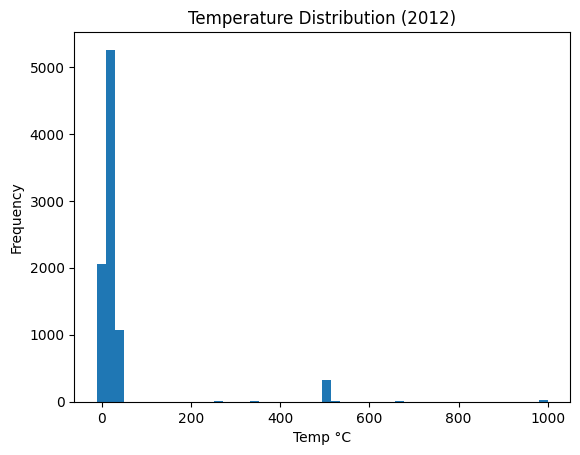

In [52]:
import matplotlib.pyplot as plt

plt.hist(hourly_stats["mean"], bins=50)
plt.title("Temperature Distribution (2012)")
plt.xlabel("Temp °C")
plt.ylabel("Frequency")
plt.show()

## Dataset 2: METAR Airport Weather Observations

### Objective

Our second weather dataset will come from **METAR aviation weather observations**.

METAR reports are standardized hourly weather observations produced by airports
around the world. These reports include information such as:

- temperature
- dew point
- wind speed and direction
- visibility
- precipitation
- atmospheric pressure
- cloud coverage

For this project we will retrieve METAR observations from:

**Station:** KOKC  
**Location:** Will Rogers World Airport (Oklahoma City)

### Why Are We Collecting This Data?

This dataset will allow us to compare multiple independent weather sources.

Our project goal is to study **agreement between weather data sources**, which means
we want to measure how often different systems report similar or conflicting weather
conditions.

We currently have:

| Source | Type |
|------|------|
NOAA ISD | historical weather archive |
METAR | airport observations |
Forecast API | predicted weather |

METAR will serve as an **independent observational dataset** that we can later compare
against the NOAA dataset and forecast models.

### Output

The dataset will be saved to:


data/raw/metar_okc_2012.csv


We are intentionally storing raw data without modification so that the original
source data is preserved.


### Plan for Retrieving METAR Data

To retrieve the METAR dataset we will use a publicly available data service
provided by the **Iowa Environmental Mesonet (IEM)**.

This service allows us to download historical METAR observations as CSV files.

The process will involve the following steps:

1. Define the weather station we want to analyze
2. Define the date range of interest (2012)
3. Construct a request to the Mesonet data service
4. Send the request using Python's `requests` library
5. Save the returned CSV data to our raw data directory
6. Verify that the dataset downloaded correctly

Each of these steps will be implemented carefully so that the notebook
remains readable and reproducible.

### Step 1: Define Request Parameters

Before we download the METAR dataset we must define the parameters of the request.

The important parameters include:

- **Station ID** — KOKC (Oklahoma City airport)
- **Date Range** — January 1, 2012 through December 31, 2012
- **Output Format** — CSV
- **Timezone** — UTC

We will also define the location where the dataset will be stored so that
our project maintains a consistent directory structure.

In [53]:
from pathlib import Path

# ----------------------------------------
# Define project paths
# ----------------------------------------

raw_data_directory = Path("data/raw")

# ----------------------------------------
# Define METAR dataset parameters
# ----------------------------------------

metar_station_identifier = "KOKC"

metar_start_year = 2012
metar_start_month = 1
metar_start_day = 1

metar_end_year = 2012
metar_end_month = 12
metar_end_day = 31

# ----------------------------------------
# Define output file location
# ----------------------------------------

metar_output_file = raw_data_directory / "metar_okc_2012.csv"

print("Station:", metar_station_identifier)
print("Date range:", f"{metar_start_year}-01-01 through {metar_end_year}-12-31")
print("Output file:", metar_output_file)

Station: KOKC
Date range: 2012-01-01 through 2012-12-31
Output file: data\raw\metar_okc_2012.csv


### Explanation of the Parameter Setup

In the previous step we defined all parameters required for the METAR request.

Several design choices were intentional:

**Readable variable names**

Instead of short names like `s` or `yr`, we use descriptive variable names
such as `metar_station_identifier` and `metar_start_year`. This improves
readability for students and collaborators.

**Explicit date components**

Breaking the date into year/month/day components makes the request parameters
clear and easy to modify later if we wish to analyze additional years.

**Centralized output path**

All raw datasets are stored inside:


data/raw/


Maintaining a strict directory structure ensures that later notebooks
(`02_clean_and_align.ipynb`) can reliably locate input datasets.


### Step 1: Define Request Parameters

Before we download the METAR dataset we must define the parameters of the request.

The important parameters include:

- **Station ID** — KOKC (Oklahoma City airport)
- **Date Range** — January 1, 2012 through December 31, 2012
- **Output Format** — CSV
- **Timezone** — UTC

We will also define the location where the dataset will be stored so that
our project maintains a consistent directory structure.

In [54]:
from pathlib import Path

# ----------------------------------------
# Define project paths
# ----------------------------------------

raw_data_directory = Path("data/raw")

# ----------------------------------------
# Define METAR dataset parameters
# ----------------------------------------

metar_station_identifier = "KOKC"

metar_start_year = 2012
metar_start_month = 1
metar_start_day = 1

metar_end_year = 2012
metar_end_month = 12
metar_end_day = 31

# ----------------------------------------
# Define output file location
# ----------------------------------------

metar_output_file = raw_data_directory / "metar_okc_2012.csv"

print("Station:", metar_station_identifier)
print("Date range:", f"{metar_start_year}-01-01 through {metar_end_year}-12-31")
print("Output file:", metar_output_file)

Station: KOKC
Date range: 2012-01-01 through 2012-12-31
Output file: data\raw\metar_okc_2012.csv


### Explanation of the Parameter Setup

In the previous step we defined all parameters required for the METAR request.

Several design choices were intentional:

**Readable variable names**

Instead of short names like `s` or `yr`, we use descriptive variable names
such as `metar_station_identifier` and `metar_start_year`. This improves
readability for students and collaborators.

**Explicit date components**

Breaking the date into year/month/day components makes the request parameters
clear and easy to modify later if we wish to analyze additional years.

**Centralized output path**

All raw datasets are stored inside:


data/raw/


Maintaining a strict directory structure ensures that later notebooks
(`02_clean_and_align.ipynb`) can reliably locate input datasets.


### Step 2: Construct the METAR Data Request

Now that the parameters are defined we will construct the request
that will be sent to the Mesonet METAR archive service.

This request will include:

- station identifier
- date range
- desired output format
- additional metadata such as latitude, longitude, and elevation

Once the request is constructed we will send it to the server
and retrieve the dataset.

In [55]:
import requests

mesonet_request_url = "https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py"

metar_request_parameters = {

    "station": metar_station_identifier,

    "data": "all",

    "year1": metar_start_year,
    "month1": metar_start_month,
    "day1": metar_start_day,

    "year2": metar_end_year,
    "month2": metar_end_month,
    "day2": metar_end_day,

    "tz": "UTC",
    "format": "onlycomma",

    "latlon": "yes",
    "elev": "yes",

    "missing": "M",
    "trace": "T",

    "direct": "yes",

    "report_type": "1",
    "report_type": "2"
}

print("METAR request parameters constructed successfully.")

METAR request parameters constructed successfully.


### Understanding the METAR Request

The parameters provided to the Mesonet service control exactly what
data will be returned.

Important options include:

**station**

The airport weather station identifier.

Example:


KOKC


**format = onlycomma**

Requests a clean comma-separated file so the data can easily be
loaded into pandas.

**latlon = yes**

Includes geographic coordinates for the station.

**elev = yes**

Includes station elevation which may be useful for analysis.

The remaining parameters ensure that the service returns a
complete dataset without filtering out any weather observations.



In [56]:
metar_response = requests.get(
    mesonet_request_url,
    params=metar_request_parameters
)

print("Server response code:", metar_response.status_code)

if metar_response.status_code == 200:

    with open(metar_output_file, "w", encoding="utf-8") as file_handle:
        file_handle.write(metar_response.text)

    print("METAR dataset successfully saved.")

else:
    print("Download failed.")

Server response code: 200
METAR dataset successfully saved.


### Step 3: Verify the Downloaded Dataset

After retrieving the METAR dataset we should verify that the file
was downloaded correctly and contains usable data.

We will load the dataset into pandas and inspect:

- number of rows
- number of columns
- sample records

This step ensures that our data pipeline is functioning properly
before we move on to the next data source.

In [57]:
import pandas as pd

metar_dataframe = pd.read_csv(metar_output_file)

print("Dataset shape:", metar_dataframe.shape)

metar_dataframe.head()

Dataset shape: (9890, 33)


,station,valid,lon,lat,elevation,tmpf,dwpf,relh,drct,sknt,...,wxcodes,ice_accretion_1hr,ice_accretion_3hr,ice_accretion_6hr,peak_wind_gust,peak_wind_drct,peak_wind_time,feel,metar,snowdepth
0,OKC,2012-01-01 00:52,-97.6006,35.3889,397.0,59.00,25.00,26.90,330.00,21.00,...,M,M,M,M,29.00,330.00,2012-01-01 00:18,59.00,KOKC 010052Z 33021G27KT 10SM FEW250 15/M04 A29...,M
1,OKC,2012-01-01 01:52,-97.6006,35.3889,397.0,56.00,20.00,24.29,320.00,18.00,...,M,M,M,M,28.00,330.00,2012-01-01 01:47,55.94,KOKC 010152Z 32018G28KT 10SM FEW250 13/M07 A30...,M
2,OKC,2012-01-01 02:52,-97.6006,35.3889,397.0,52.00,28.00,39.40,310.00,28.00,...,M,M,M,M,38.00,310.00,2012-01-01 02:50,51.98,KOKC 010252Z 31028G38KT 8SM CLR 11/M02 A3008 R...,M
3,OKC,2012-01-01 03:52,-97.6006,35.3889,397.0,47.00,31.00,53.47,330.00,32.00,...,M,M,M,M,50.00,340.00,2012-01-01 03:44,36.96,KOKC 010352Z 33032G50KT 8SM CLR 08/M01 A3013 R...,M
4,OKC,2012-01-01 04:52,-97.6006,35.3889,397.0,45.00,31.00,57.63,330.00,24.00,...,M,M,M,M,43.00,330.00,2012-01-01 03:55,35.54,KOKC 010452Z 33024G33KT 10SM CLR 07/M01 A3019 ...,M
